<a href="https://colab.research.google.com/github/ChettoKun/Fenomenos_transporte_ii/blob/Parte_I/Problemario_Coordenadas_Cilindricas_Jorge_Cancino_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#PROBLEMAS CON LA ECUACION DE CONDUCCION DE CALOR EN DOS DIMENSIONES: COORDENADAS CILINDRICAS

## Problemas con la Ecuación de Laplace

### Problema 1:
Encuentra la distribución de temperatura $T(r, z)$ en un cilindro largo y delgado donde la ecuación
de Laplace es:
$$\frac{1}{r}\frac{\partial}{\partial r} \left(r \frac{\partial T}{\partial r} \right) + \frac{\partial^2 T}{\partial z^2}=0$$

Condiciones de frontera y valores:
* En la superficie lateral del cilindro $(r = R = 0,1 m)$, la temperatura es constante: $T(0,1, z) = 50^{\circ} C$.
* En el centro del cilindro $(r = 0)$, no hay flujo de calor:  $\frac{\partial T}{\partial r}= 0$.
* En los extremos ($z = 0$ y $z = L = 1 m$), la temperatura es cero: $T(r, 0) = T(r, 1) = 0^{\circ} C$.


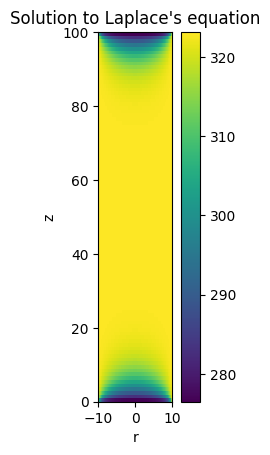

In [ ]:
from pde import *
T1=50+273.15
T2=0+273.15
T3=0+273.15
grid=CylindricalSymGrid(radius=[0,10], bounds_z=[0,100],shape=[100,100])#centimetros

#bounds
bc_r=[{"derivative":0},
      {"value":T1}]
bc_z=[{"value":T2},
      {"value":T3}]
ecuacion=solve_laplace_equation(grid,bc=[bc_r,bc_z])
ecuacion.plot(kind="image")

### Problema 2:
Determina la distribución de temperatura en un tubo cilíndrico con paredes aisladas bajo la ecuación de Laplace:
$$\frac{1}{r}\frac{\partial}{\partial r} \left(r \frac{\partial T}{\partial r} \right) + \frac{\partial^2 T}{\partial z^2}=0$$

Condiciones de frontera y valores:
* En el borde externo del cilindro $(r = R = 0,2 m)$, la derivada de la temperatura respecto a r es cero: $\frac{\partial T}{\partial r} = 0$.
* En el eje central del cilindro ($r = 0$), la derivada de la temperatura respecto a r es cero: $\frac{\partial T}{\partial r} = 0$.
* En el extremo inferior del cilindro ($z = 0$), la temperatura es constante: $T(r, 0) = 100^{\circ} C$.
* En el extremo superior ($z = L = 1 m$), la temperatura es cero: $T(r, 1) = 0^{\circ} C$.

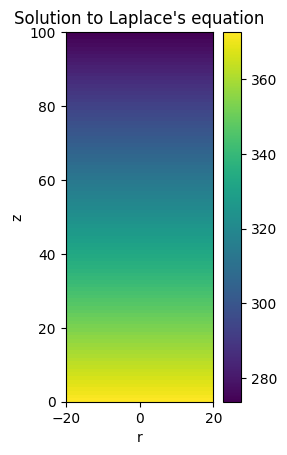

In [ ]:
from pde import *
T2=100+273.15
T3=0+273.15
grid=CylindricalSymGrid(radius=[0,20], bounds_z=[0,100],shape=[100,100])#centimetros

#bounds
bc_r=[{"derivative":0},
      {"derivative":0}]
bc_z=[{"value":T2},
      {"value":T3}]
ecuacion=solve_laplace_equation(grid,bc=[bc_r,bc_z])
ecuacion.plot()

## Problemas con la Ecuación de Poisson

### Problema 3
Se tiene un cilindro con una fuente interna de generación de calor uniforme de intensidad $q = 500\ W/m^3$. La ecuación de Poisson es:
$$\frac{1}{r}\frac{\partial}{\partial r} \left(r \frac{\partial T}{\partial r} \right) + \frac{\partial^2 T}{\partial z^2}=-\frac{q}{k}$$
donde $k = 10\ W/m \cdot K$.

Condiciones de frontera y valores:
* En la superficie externa del cilindro (r = R = 0,05 m), la temperatura es constante: $T(0,05, z) = 80^{\circ} C$.
* En el eje central del cilindro (r = 0), la derivada de la temperatura respecto a r es cero: $\frac{\partial T}{\partial r} = 0$.
* En los extremos del cilindro ($z = 0$ y $z = L=0,05m$), la temperatura es cero: $T(r, 0) = T(r, 0.05)= 0^{\circ} C$.


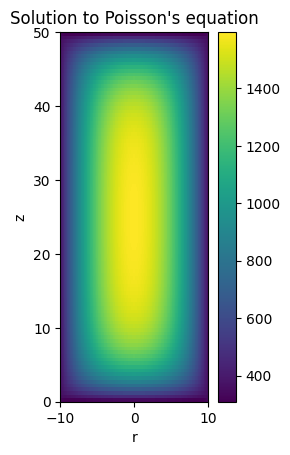

In [ ]:
from pde import *
q0=500 #W/m^3
k=10 #W/m*k
T1=80+273.15  #k
T2=0+273.15   #k
T3=0+273.15 #k
CI=-q0/k
grid=CylindricalSymGrid(radius=[0,10], bounds_z=[0,50],shape=[100,100])
field=ScalarField(grid,CI)

#bounds
bc_r=[{"derivative":0},
      {"value":T1}]
bc_z=[{"value":T2},
      {"value":T3}]
ecuacion=solve_poisson_equation(field,bc=[bc_r,bc_z])
ecuacion.plot()

### Problema 4
Encuentra la distribución de temperatura en un cilindro con una fuente de calor interna que varía linealmente en $z$, es decir, $q(z) = q_0z$ con $q0 = 200W/m^4$ . La ecuación de Poisson es:
$$\frac{1}{r}\frac{\partial}{\partial r} \left(r \frac{\partial T}{\partial r} \right) + \frac{\partial^2 T}{\partial z^2}=-\frac{q(z)}{k}=-\frac{200z}{k}$$

donde $k=15\ W/m \cdot K$.
Condiciones de frontera y valores:
* En la superficie del cilindro ($r = R = 0,1 m$), la temperatura es constante: $T(0,1, z) = 60 ^{\circ}C$.
* En el centro del cilindro ($r = 0$), la derivada de la temperatura respecto a $r$ es cero: $\frac{\partial T}{\partial r}= 0$.
* En el extremo inferior ($z = 0$), la temperatura es cero: $T(r, 0) = 0 ^{\circ}C$.
* En el extremo superior ($z = L = 0,5 m$), la temperatura es $T(r, 0,5) = 100 ^{\circ}C$.


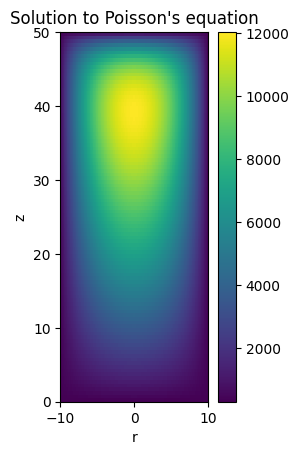

In [ ]:
from pde import *
q0=200
k=15
T1=60+273.15
T2=0+273.15
T3=100+273.15
CI=f"-{q0}*z/{k}"
grid=CylindricalSymGrid(radius=[0,10], bounds_z=[0,50],shape=[100,100])
field=ScalarField.from_expression(grid,CI)

#bounds
bc_r=[{"derivative":0},
      {"value":T1}]
bc_z=[{"value":T2},
      {"value":T3}]
ecuacion=solve_poisson_equation(field,bc=[bc_r,bc_z])
ecuacion.plot()

## Problemas con la Ecuación de Difusión

### Problema 5
Encuentra la evolución temporal de la temperatura en un cilindro, donde la ecuación de difusión es:
$$\alpha \left(\frac{1}{r}\frac{\partial}{\partial r} \left(r \frac{\partial T}{\partial r} \right) + \frac{\partial^2 T}{\partial z^2} \right)=\frac{\partial T}{\partial t}$$

con $\alpha = 0,01 m^2/s$

Condiciones iniciales y de frontera:
* La temperatura inicial es cero en todo el cilindro: $T(r, z, 0) = 0^{\circ}C$.
* En la superficie lateral del cilindro ($r = R = 0,05 \ m$), la temperatura se mantiene constante: $T(0,05, z, t) = 75 ^{\circ}C$.
* En el eje central del cilindro ($r = 0$), no hay flujo de calor: $\frac{\partial T}{\partial r}= 0$
* En los extremos ($z = 0$ y $z = L = 1\ m$), la temperatura es cero: $T(r, 0, t) = T(r, 1, t) = 0 ^{\circ}C$.

Output()

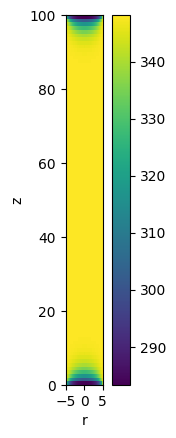

Output()

In [ ]:
from pde import *
alpha=0.01*(100**2)# #cm^2
T1=75+273.15
T2=0+273.15
T3=0+273.15
CI=0+273.15
grid=CylindricalSymGrid(radius=[0,5], bounds_z=[0,100],shape=[100,100])
field=ScalarField(grid,CI)

#bounds
bc_r=[{"derivative":0},
      {"value":T1}]
bc_z=[{"value":T2},
      {"value":T3}]
ecuacion=PDE({"T":f"laplace(T)*{alpha}"},bc=[bc_r,bc_z])
tracker=LivePlotTracker(interrupts=0.1,plot_args={"kind":"image"})
solucion=ecuacion.solve(field, t_range=1,dt=0.000001,tracker=tracker)
solucion.plot()

### Problema 6
Considera un cilindro con una fuente de calor que se apaga en $t = 0$. La ecuación de difusión es:
$$\alpha \left(\frac{1}{r}\frac{\partial}{\partial r} \left(r \frac{\partial T}{\partial r} \right) + \frac{\partial^2 T}{\partial z^2} \right)=\frac{\partial T}{\partial t}$$

con $\alpha = 0,005\ m^2/s$

Condiciones iniciales y de frontera:
* Condición inicial: $T(r, z, 0) = 100 ^{\circ}C$ en todo el cilindro.
* En el borde lateral del cilindro ($r = R = 0,1 m$), la derivada de la temperatura respecto a $r$ es cero: $\frac{\partial T}{\partial r}= 0$
* En el eje del cilindro ($r = 0$), no hay flujo de calor: $\frac{\partial T}{\partial r}= 0$
* En los extremos ($z = 0$ y $z = L = 0,3 m$), también hay aislamiento: $\frac{\partial T}{\partial z}= 0$

Output()

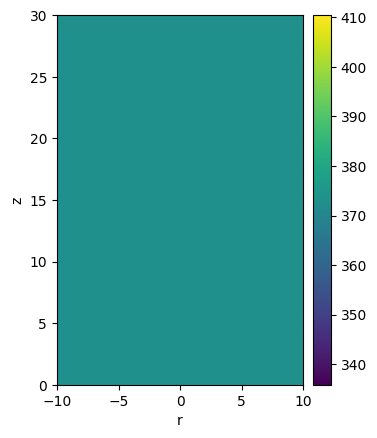

In [ ]:
from pde import *
alpha=0.005*(100**2)# #cm^2
T1=75+273.15
T2=0+273.15
T3=0+273.15
CI=100+273.15
grid=CylindricalSymGrid(radius=[0,10], bounds_z=[0,30],shape=[100,100])
field=ScalarField(grid,CI)

#bounds
bc_r=[{"derivative":0},
      {"derivative":0}]
bc_z=[{"derivative":0},
      {"derivative":0}]
ecuacion=PDE({"T":f"laplace(T)*{alpha}"},bc=[bc_r,bc_z])
tracker=LivePlotTracker(interrupts=0.1,plot_args={"kind":"image"})
solucion=ecuacion.solve(field, t_range=5,dt=0.0001,tracker=tracker)
solucion.plot()

In [ ]:
%pip install py-pde

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.9/322.9 kB 4.1 MB/s eta 0:00:00
